In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')

In [60]:
## read the dataset

df = pd.read_csv('dataset.csv')

In [61]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [62]:
## check null values in dataset

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [63]:
df.shape

(32561, 15)

In [64]:
df.columns = ['age', 'workclass', 'final_weight', 'education', 'education_num', 'martial_status', 'occupation', 'relationship', 'race', 'sex',
             'capital_gain', 'capital_loss', 'hrs_per_week', 'native_country', 'income']

In [65]:
df.columns

Index(['age', 'workclass', 'final_weight', 'education', 'education_num',
       'martial_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hrs_per_week', 'native_country',
       'income'],
      dtype='object')

In [66]:
df.income.unique()

array([' <=50K', ' >50K'], dtype=object)

In [67]:
## converting income columns to 0's and 1's {0 for salary <=50K and 1 for salary >50K}
df['income'] = [1 if value == ' >50K' else 0 for value in df['income'].values]

In [68]:
## last 5 rows in dataset

df.tail()

,age,workclass,final_weight,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hrs_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,1


In [69]:
df.workclass.unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [70]:
## removing ? from column workclass
df['workclass'] = np.where(df.workclass == ' ?', np.nan, df['workclass'])

In [71]:
df.dropna(axis=0, inplace=True)

In [72]:
workclass_label = {v:k for k, v in enumerate(df.workclass.unique())}

In [73]:
workclass_label

{' State-gov': 0,
 ' Self-emp-not-inc': 1,
 ' Private': 2,
 ' Federal-gov': 3,
 ' Local-gov': 4,
 ' Self-emp-inc': 5,
 ' Without-pay': 6,
 ' Never-worked': 7}

In [74]:
df.workclass = df.workclass.map(workclass_label)

In [75]:
df.education.unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' Preschool',
       ' 12th', ' 1st-4th'], dtype=object)

In [76]:
education_label = {v:k for k, v in enumerate(df.education.unique())}

In [77]:
education_label

{' Bachelors': 0,
 ' HS-grad': 1,
 ' 11th': 2,
 ' Masters': 3,
 ' 9th': 4,
 ' Some-college': 5,
 ' Assoc-acdm': 6,
 ' Assoc-voc': 7,
 ' 7th-8th': 8,
 ' Doctorate': 9,
 ' Prof-school': 10,
 ' 5th-6th': 11,
 ' 10th': 12,
 ' Preschool': 13,
 ' 12th': 14,
 ' 1st-4th': 15}

In [78]:
df.education = df.education.map(education_label)

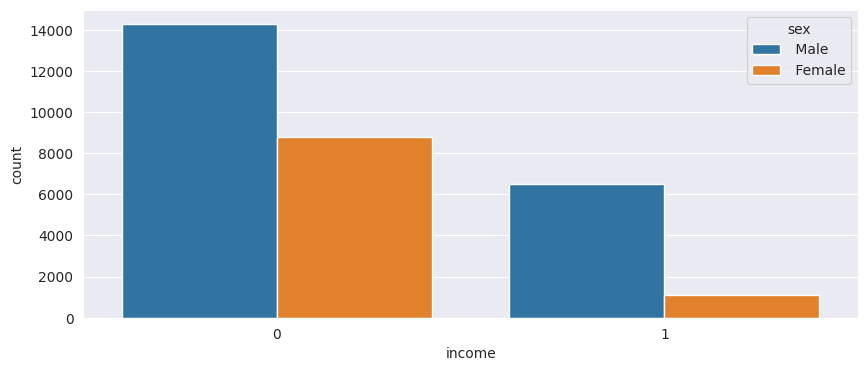

In [79]:
plt.figure(figsize=(10, 4))
sns.countplot(x='income', data=df, hue='sex');

TypeError: barplot() takes from 0 to 1 positional arguments but 2 were given

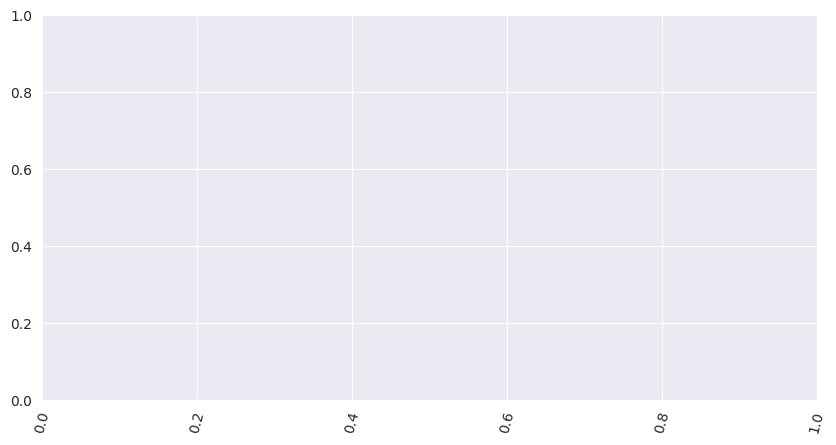

In [80]:
native_country = df.native_country.value_counts().nlargest(5)

plt.figure(figsize=(10, 5))
plt.xticks(rotation=75)
sns.barplot(native_country.index, np.log(native_country));

In [ ]:
df.native_country = np.where(df.native_country == ' ?', np.nan, df['native_country'])

In [ ]:
df.dropna(axis=0, inplace=True)

In [81]:
native_country = {v:k for k, v in enumerate(df.native_country.unique())}

In [82]:
df.native_country = df.native_country.map(native_country)

In [83]:
df.head()

,age,workclass,final_weight,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hrs_per_week,native_country,income
0,39,0,77516,0,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,0,0
1,50,1,83311,0,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,0,0
2,38,2,215646,1,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,0,0
3,53,2,234721,2,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,0,0
4,28,2,338409,0,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,1,0


In [84]:
df.martial_status.unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [85]:
marital_label = {v:k for k, v in enumerate(df.martial_status.unique())}

In [86]:
df.martial_status = df.martial_status.map(marital_label)

In [87]:
df.occupation.unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv', ' ?'], dtype=object)

In [88]:
df.occupation = np.where(df.occupation == ' ?', np.nan, df['occupation'])

In [89]:
df.dropna(axis=0, inplace=True)

In [90]:
occ_label = {v:k for k, v in enumerate(df.occupation.unique())}

In [91]:
df.occupation = df.occupation.map(occ_label)

In [92]:
df.relationship.unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [93]:
relationship_label = {v:k for k, v in enumerate(df.relationship.unique())}

In [94]:
df.relationship = df.relationship.map(relationship_label)

In [95]:
df.head()

,age,workclass,final_weight,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hrs_per_week,native_country,income
0,39,0,77516,0,13,0,0,0,White,Male,2174,0,40,0,0
1,50,1,83311,0,13,1,1,1,White,Male,0,0,13,0,0
2,38,2,215646,1,9,2,2,0,White,Male,0,0,40,0,0
3,53,2,234721,2,7,1,2,1,Black,Male,0,0,40,0,0
4,28,2,338409,0,13,1,3,2,Black,Female,0,0,40,1,0


In [96]:
df.sex = np.where(df.sex == ' Male', 1, 0)

In [97]:
df.race.unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Amer-Indian-Eskimo',
       ' Other'], dtype=object)

In [98]:
race_label = {v:k for k, v in enumerate(df.race.unique())}

In [99]:
race_label

{' White': 0,
 ' Black': 1,
 ' Asian-Pac-Islander': 2,
 ' Amer-Indian-Eskimo': 3,
 ' Other': 4}

In [100]:
df.race = df.race.map(race_label)

In [101]:
df.head()

,age,workclass,final_weight,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hrs_per_week,native_country,income
0,39,0,77516,0,13,0,0,0,0,1,2174,0,40,0,0
1,50,1,83311,0,13,1,1,1,0,1,0,0,13,0,0
2,38,2,215646,1,9,2,2,0,0,1,0,0,40,0,0
3,53,2,234721,2,7,1,2,1,1,1,0,0,40,0,0
4,28,2,338409,0,13,1,3,2,1,0,0,0,40,1,0


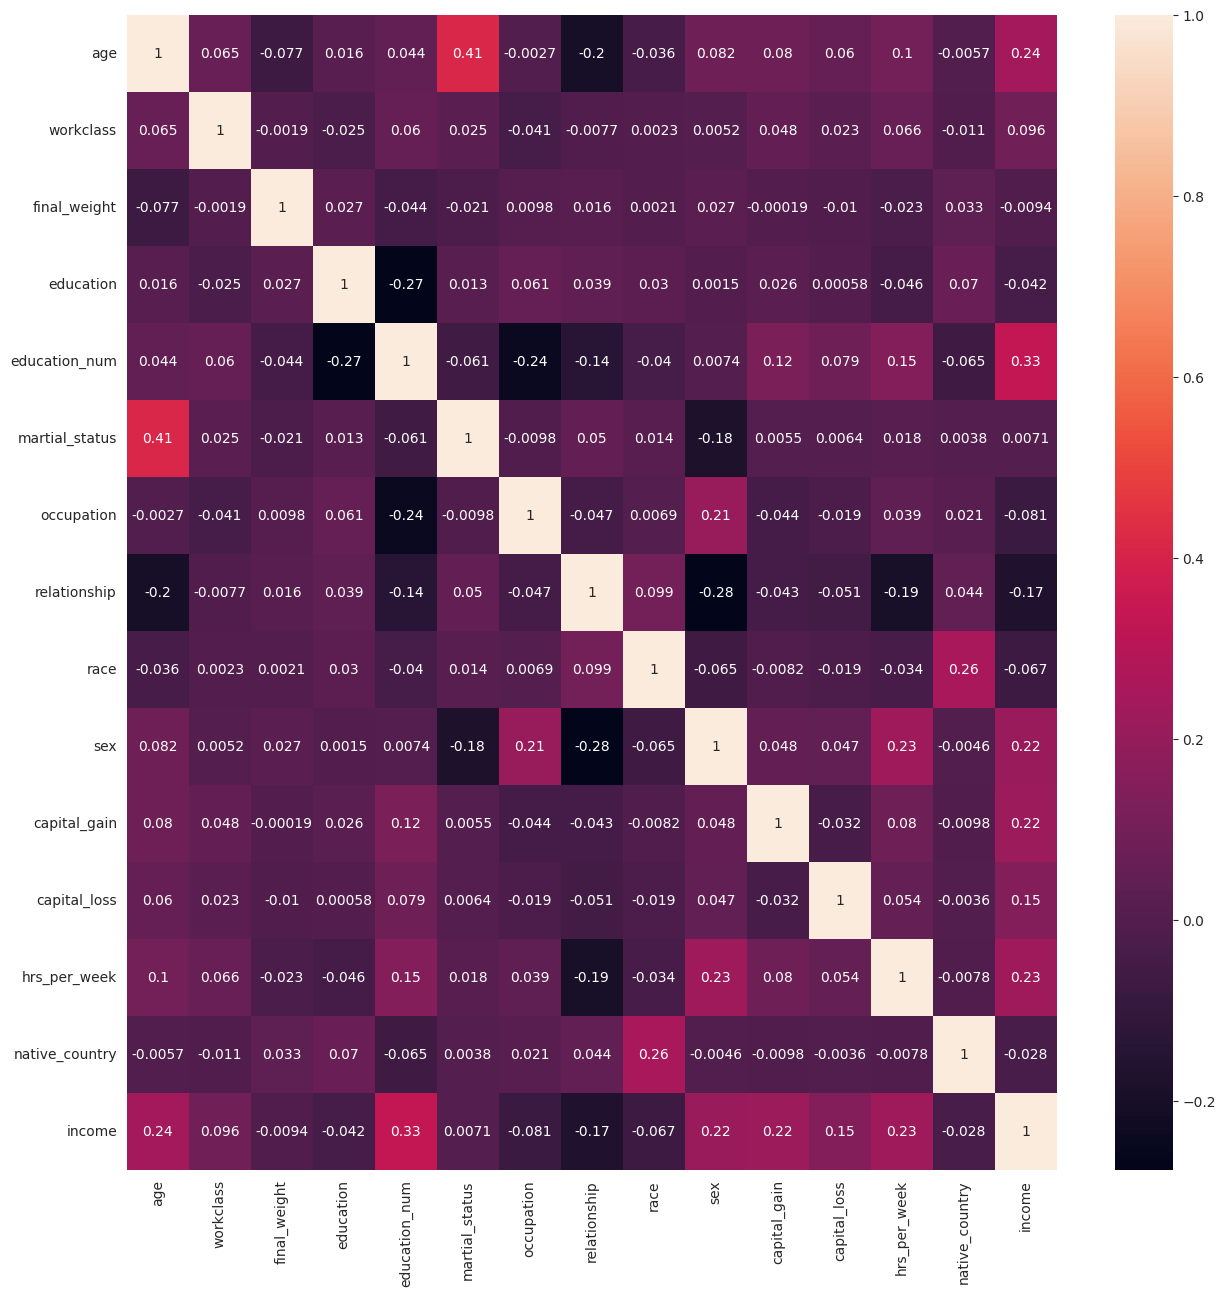

In [102]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True);

In [103]:
df.head()

,age,workclass,final_weight,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hrs_per_week,native_country,income
0,39,0,77516,0,13,0,0,0,0,1,2174,0,40,0,0
1,50,1,83311,0,13,1,1,1,0,1,0,0,13,0,0
2,38,2,215646,1,9,2,2,0,0,1,0,0,40,0,0
3,53,2,234721,2,7,1,2,1,1,1,0,0,40,0,0
4,28,2,338409,0,13,1,3,2,1,0,0,0,40,1,0


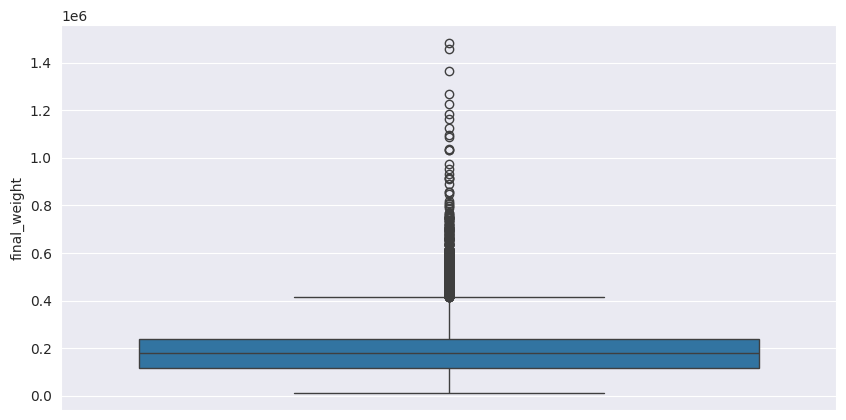

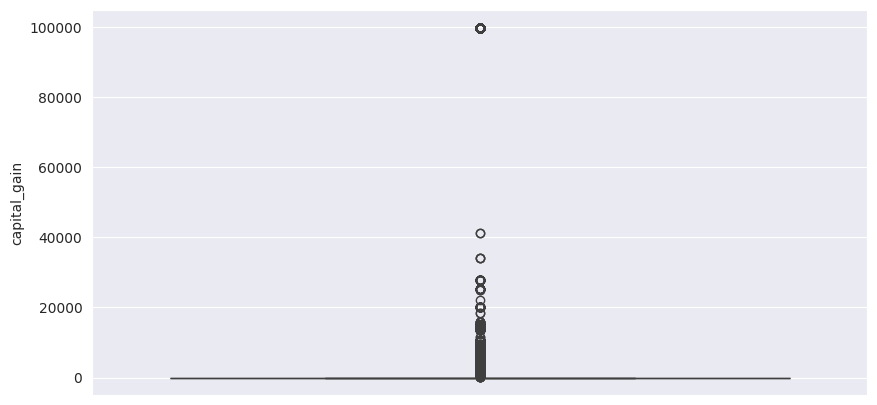

In [104]:
for feature in ['final_weight', 'capital_gain']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(df[feature])

In [105]:
df.describe()

,age,workclass,final_weight,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hrs_per_week,native_country,income
count,30718.000000,30718.000000,3.071800e+04,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000,30718.000000
mean,38.443584,2.111107,1.898455e+05,3.375545,10.130314,1.074386,4.260141,1.524285,0.218341,0.676737,1106.037079,88.910216,40.949313,1.312162,0.249040
std,13.118227,0.936743,1.054583e+05,3.415949,2.562469,1.217380,3.033611,1.433072,0.621965,0.467730,7497.863364,405.657203,11.985382,5.132219,0.432464
min,17.000000,0.000000,1.376900e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,2.000000,1.178285e+05,1.000000,9.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000
50%,37.000000,2.000000,1.785170e+05,2.000000,10.000000,1.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000,40.000000,0.000000,0.000000
75%,47.000000,2.000000,2.373170e+05,5.000000,13.000000,1.000000,6.000000,3.000000,0.000000,1.000000,0.000000,0.000000,45.000000,0.000000,0.000000
max,90.000000,6.000000,1.484705e+06,15.000000,16.000000,6.000000,13.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,41.000000,1.000000


In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [107]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [108]:
X = X.values
y = y.values

sc = StandardScaler()
sc.fit_transform(X)

array([[ 0.04241621, -2.2537041 , -1.06517328, ..., -0.2191793 ,
        -0.0792072 , -0.25567569],
       [ 0.88095778, -1.18615822, -1.01022176, ..., -0.2191793 ,
        -2.33198808, -0.25567569],
       [-0.03381484, -0.11861235,  0.24465473, ..., -0.2191793 ,
        -0.0792072 , -0.25567569],
       ...,
       [ 1.4908062 , -0.11861235, -0.35972663, ..., -0.2191793 ,
        -0.0792072 , -0.25567569],
       [-1.25351168, -0.11861235,  0.11041941, ..., -0.2191793 ,
        -1.74793378, -0.25567569],
       [ 1.03341989,  3.08402528,  0.93006469, ..., -0.2191793 ,
        -0.0792072 , -0.25567569]])

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [110]:
from sklearn.linear_model import LogisticRegression

In [111]:
lg = LogisticRegression()

In [112]:
lg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [113]:
pred = lg.predict(X_test)

In [114]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

--------------------------------------------Classification Report---------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.97      0.87      6917
           1       0.72      0.26      0.39      2299

    accuracy                           0.79      9216
   macro avg       0.76      0.61      0.63      9216
weighted avg       0.78      0.79      0.75      9216

------------------------------------------Accuracy Score---------------------------------------------------------
0.7904730902777778
--------------------------------------------Confustion Matrix-----------------------------------------------------


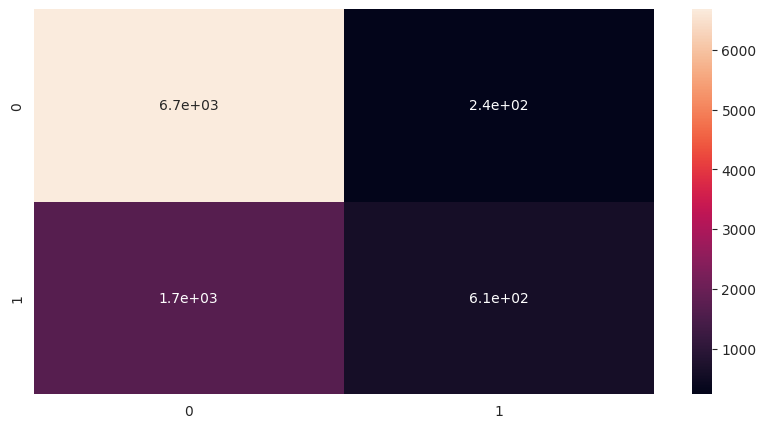

In [115]:
print("--------------------------------------------Classification Report---------------------------------------------")
print(classification_report(y_test, pred))

print("------------------------------------------Accuracy Score---------------------------------------------------------")
print(accuracy_score(y_test, pred))

print("--------------------------------------------Confustion Matrix-----------------------------------------------------")
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix(y_test, pred), annot=True);